In [2]:
from langgraph.graph import START, END, StateGraph
from typing import List, Optional, Tuple
from typing_extensions import TypedDict
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

class AgentState(TypedDict):
    prompt: str
    vectorstore: Optional[object]
    is_website: Optional[bool]
    url: Optional[List[str]]
    is_generic: Optional[bool]
    needs_web: Optional[bool]
    context_exists: Optional[bool]
    context: Optional[str]
    documents: Optional[List[str]]
    response: Optional[str]
    llm: Optional[object]
    web_search_count: Optional[int]

In [ ]:
def initialize(state: AgentState) -> AgentState:
    print("Initializing agent state...")
    state['vectorstore'] = get_vectorstore()
    #can also call the LLM thread
    return state

def check_prompt(state: AgentState) -> AgentState:
    print(f"Prompt received", {state['prompt']})
    return state

def check_link(state: AgentState) -> AgentState:
    state['url'], state['is_website'] = is_website_request(state['prompt'])
    state['vectorstore'] = get_vectorstore()
    print(f"URL received", state['url'])
    return state

def check_generic(state: AgentState) -> AgentState:
    state['is_generic'] = needs_context(state['prompt'])
    print(f"Is the prompt generic:", {state['is_generic']})
    return state

def check_needs_web_search(state: AgentState) -> AgentState:
    state['needs_web'] = few_shot_needs_web_search(state['prompt'])
    print(f"Does the prompt needs to be web searched:", {state['needs_web']})
    return state

def check_context_in_db(state: AgentState) -> AgentState:
    state['context_exists'] = has_relevant_data(state['vectorstore'], state['prompt'], state['web_search_count'])
    print(f"Context exists in DB:", {state['context_exists']})
    return state

def retrieve_context(state: AgentState) -> AgentState:
    context_list = get_relevant_context(state['vectorstore'], state['prompt'])
    state['context'] = "\n\n".join(context_list) if context_list else None
    print(f"Retrieved context:", {state['context']})
    return state

async def perform_web_search(state: AgentState) -> AgentState:
    state['documents'] = await search_and_crawl(state['prompt'], 10, state['url'])
    state['web_search_count'] += 1
    print(f"Web search documents:", state['documents'])
    return state

def add_documents_to_db(state: AgentState) -> AgentState:
    add_to_vector_database(state['vectorstore'], state['documents'])
    print("Documents added to DB")
    return state

def call_llm_state(state: AgentState) -> AgentState:
    state['response'] = call_llm(state['prompt'], state.get('context', ''))
    print(f"LLM Response:", {state['response']})
    return state

def finish(state: AgentState) -> AgentState:
    print("Final state reached.")
    return state

def analyze(state: AgentState) -> AgentState:
    print("Intent analyzed.")
    return state

def enhance(state: AgentState) -> AgentState:
    print("Prompt enhanced.")
    return state

def human_interrupt_node(state: AgentState):
    """
    This node leverages the LangGraph interrupt function to pause the workflow,
    present the current prompt (or other text) to the human, and wait for a revision.
    """
    revised_prompt = interrupt({
        "text_to_revise": state.get("prompt", "No prompt provided."),
        "instruction": "Please revise the prompt as needed."
    })
    state["prompt"] = revised_prompt
    # Return a new state with the human's revision.
    return state

def user_input_needed(state: AgentState):
    state["inputs_needed"] = input_needed(state["prompt"])
    return state

In [ ]:
workflow = StateGraph(AgentState)
# Add nodes
# workflow.add_node("initialize_vector_db", initialize)
workflow.add_node("check_prompt_exists", check_prompt)
workflow.add_node("analyze_intent", analyze)
workflow.add_node("enhance_prompt", enhance)
workflow.add_node("user_input_needed", user_input_needed)
workflow.add_node("human_interrupt", human_interrupt_node)
workflow.add_node("check_generic_query", check_generic)
workflow.add_node("check_database", check_context_in_db)
workflow.add_node("web_search_needed", check_needs_web_search)
workflow.add_node("perform_web_search", perform_web_search)
workflow.add_node("add_documents_to_db", add_documents_to_db)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("call_llm", call_llm_state)
workflow.add_node("check_link", check_link)

# Define edges
workflow.add_edge(START, "check_prompt_exists")
workflow.add_edge("check_prompt_exists", "analyze_intent")
workflow.add_conditional_edges(
    "analyze_intent", 
    lambda state: state["is_website"],
    {"ethical": "enhance_prompt", "unethical": END}
)
workflow.add_edge("enhance_prompt", "user_input_needed")
workflow.add_conditional_edges(
    "user_input_needed",
    lambda state: state.get("requires_human_input", False),
    {True: "human_interrupt", False: "check_link"}
)
workflow.add_edge("human_interrupt", "check_prompt_exists")
workflow.add_conditional_edges(
    "check_link", 
    lambda state: state["is_website"],
    {True: "perform_web_search", False: "check_generic_query"}
)
# workflow.add_edge("check_prompt_exists","initialize_vector_db")
# workflow.add_edge("initialize_vector_db", "check_generic_query")
workflow.add_conditional_edges(
    "check_generic_query", 
    lambda state: state["is_generic"],
    {True: "call_llm", False: "check_database"}
)
workflow.add_conditional_edges(
    "check_database",
    lambda state: state["context_exists"],
    {True: "retrieve_context", False: "web_search_needed"}
)
workflow.add_conditional_edges(
    "web_search_needed",
    lambda state: state["needs_web"],
    {False: "call_llm", True: "perform_web_search"}
)
workflow.add_edge("perform_web_search", "add_documents_to_db")
workflow.add_edge("add_documents_to_db", "check_database")
workflow.add_edge("retrieve_context", "call_llm")
workflow.add_edge("call_llm", END)

# Compile the workflow
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

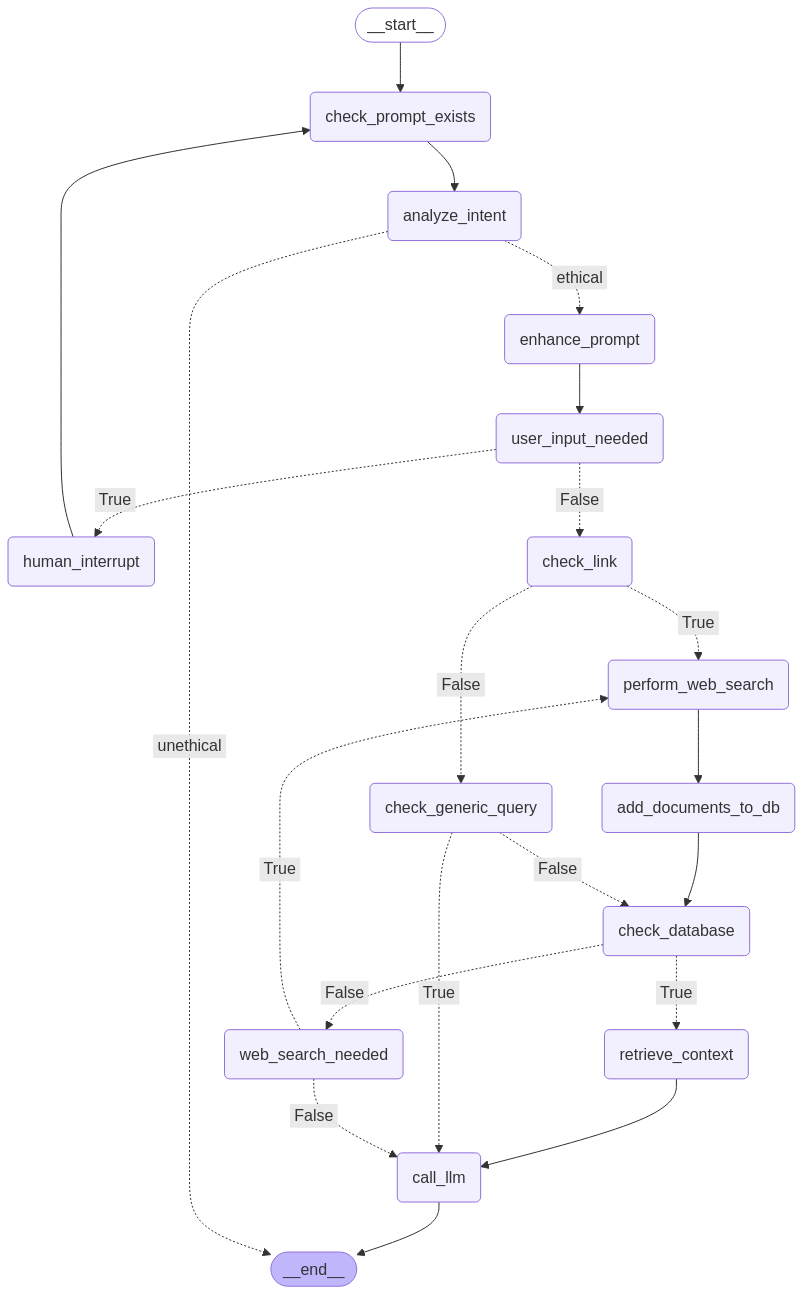

In [8]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [5]:
# Example usage:
# To run the graph until an interrupt is reached, you would call:
# result = app.invoke({"prompt": "Initial prompt text", "is_website": True, ...}, config={"configurable": {"thread_id": "unique_thread_id"}})
#
# When the human_interrupt node is hit, the execution will pause, and the interface
# will display the interrupt message (including "text_to_revise" and "instruction").
#
# After the human provides revised input, resume execution with:
# app.invoke(Command(resume="Revised prompt text"), config={"configurable": {"thread_id": "unique_thread_id"}})

In [9]:
# Placeholder functions (implement these based on your specific logic)
def check_prompt(state: AgentState) -> AgentState:
    state["prompt_exists"] = bool(state.get("prompt"))
    return state

def analyze(state: AgentState) -> AgentState:
    # Analyze intent and set is_ethical flag
    state["is_ethical"] = True  # Placeholder logic
    return state

def enhance(state: AgentState) -> AgentState:
    # Enhance the prompt
    state["enhanced_prompt"] = state.get("prompt", "") + " [enhanced]"
    return state

def user_input_needed(state: AgentState) -> AgentState:
    # Check if human input is required
    state["requires_human_input"] = False  # Placeholder logic
    return state

def human_interrupt_node(state: AgentState) -> AgentState:
    # Handle human input
    return state

def check_client_db(state: AgentState) -> AgentState:
    # Query the client's vector DB with the enhanced prompt
    state["context"] = "Retrieved context from client DB"  # Placeholder
    return state

def check_context_sufficiency(state: AgentState) -> AgentState:
    # Determine if context is sufficient (e.g., similarity score > threshold)
    state["context_sufficient"] = True  # Placeholder logic
    return state

def check_generic(state: AgentState) -> AgentState:
    # Check if the query is generic
    state["is_generic"] = False  # Placeholder logic
    return state

def check_needs_web_search(state: AgentState) -> AgentState:
    # Check if a web search is needed
    state["needs_web"] = True  # Placeholder logic
    return state

def perform_web_search(state: AgentState) -> AgentState:
    # Perform web search
    state["web_results"] = "Web search results"
    return state

def add_documents_to_db(state: AgentState) -> AgentState:
    # Add web results to the DB
    return state

def call_llm_state(state: AgentState) -> AgentState:
    # Call the LLM with the context
    state["response"] = "LLM response"
    return state

# Define the workflow
workflow = StateGraph(AgentState)

# Add nodes to the workflow
workflow.add_node("check_prompt_exists", check_prompt)
workflow.add_node("analyze_intent", analyze)
workflow.add_node("enhance_prompt", enhance)
workflow.add_node("user_input_needed", user_input_needed)
workflow.add_node("human_interrupt", human_interrupt_node)
workflow.add_node("check_client_db", check_client_db)  # Check client's vector DB
workflow.add_node("check_context_sufficiency", check_context_sufficiency)  # Check context sufficiency
workflow.add_node("check_generic_query", check_generic)
workflow.add_node("web_search_needed", check_needs_web_search)
workflow.add_node("perform_web_search", perform_web_search)
workflow.add_node("add_documents_to_db", add_documents_to_db)
workflow.add_node("call_llm", call_llm_state)

# Define edges between nodes
workflow.add_edge(START, "check_prompt_exists")
workflow.add_edge("check_prompt_exists", "analyze_intent")
workflow.add_conditional_edges(
    "analyze_intent",
    lambda state: "enhance_prompt" if state["is_ethical"] else END,
    {"enhance_prompt": "enhance_prompt", END: END}
)
workflow.add_edge("enhance_prompt", "user_input_needed")
workflow.add_conditional_edges(
    "user_input_needed",
    lambda state: "human_interrupt" if state.get("requires_human_input", False) else "check_client_db",
    {"human_interrupt": "human_interrupt", "check_client_db": "check_client_db"}
)
workflow.add_edge("human_interrupt", "check_prompt_exists")
workflow.add_edge("check_client_db", "check_context_sufficiency")
workflow.add_conditional_edges(
    "check_context_sufficiency",
    lambda state: "call_llm" if state["context_sufficient"] else "check_generic_query",
    {"call_llm": "call_llm", "check_generic_query": "check_generic_query"}
)
workflow.add_conditional_edges(
    "check_generic_query",
    lambda state: "call_llm" if state["is_generic"] else "web_search_needed",
    {"call_llm": "call_llm", "web_search_needed": "web_search_needed"}
)
workflow.add_conditional_edges(
    "web_search_needed",
    lambda state: "perform_web_search" if state["needs_web"] else "call_llm",
    {"perform_web_search": "perform_web_search", "call_llm": "call_llm"}
)
workflow.add_edge("perform_web_search", "add_documents_to_db")
workflow.add_edge("add_documents_to_db", "check_client_db")  # Loop back to check DB
workflow.add_edge("call_llm", END)

# Compile the workflow with a memory saver
checkpointer = MemorySaver()
personilized_app = workflow.compile(checkpointer=checkpointer)

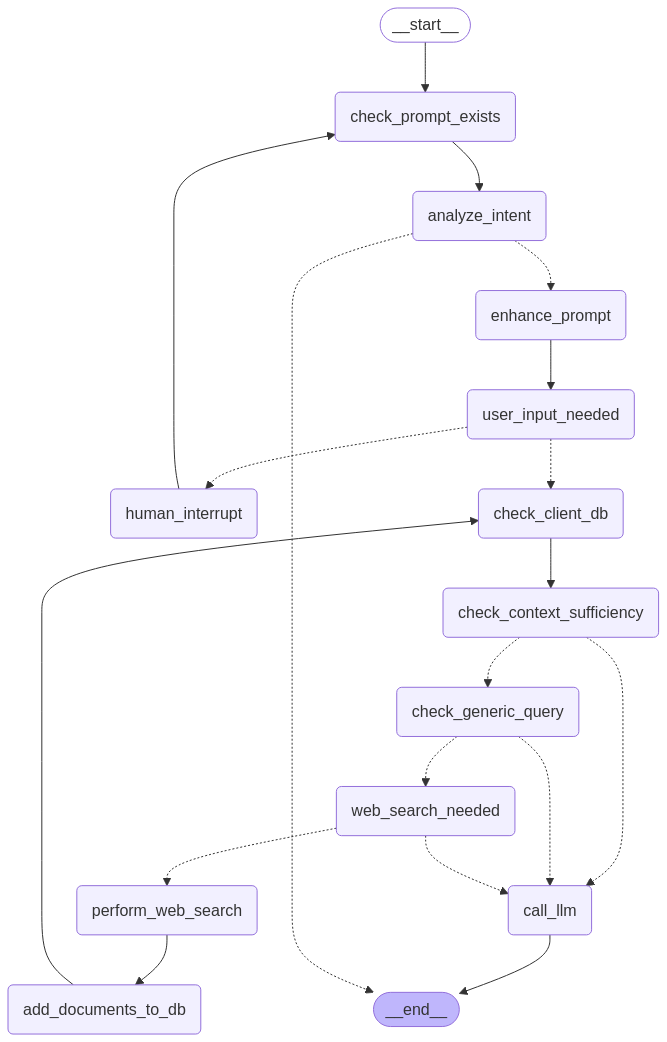

In [10]:
from IPython.display import Image, display

try:
    display(Image(personilized_app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass

In [ ]:
# Example usage
initial_state = AgentState({"prompt": "What is the weather like?"})
result = personilized_app.invoke(initial_state)
print(result)